# Fraud Detection — Model Explainability with SHAP

## Why Explainability Still Matters

A fraud model should be inspectable, especially when it may block legitimate customers or route cases to analysts. In this project, SHAP is used to understand which anonymized PCA components push predictions toward or away from fraud.

Important limitation: the Kaggle dataset anonymizes `V1`-`V28`, so these features cannot be translated into real business concepts. The explanations below are useful for model debugging and portfolio demonstration, not for customer-facing decline explanations.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import shap
import warnings
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, precision_recall_curve

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
shap.initjs()

DB_PATH     = Path('../data/fraud_detection.db')
MODELS_PATH = Path('../models')
FRAUD_COLOR, LEGIT_COLOR = '#e74c3c', '#2ecc71'

conn = sqlite3.connect(DB_PATH)
print('Connected to', DB_PATH)

Connected to ..\data\fraud_detection.db


## 1. Load Data, Model, and Scaler

In [2]:
df = pd.read_sql_query("""
    SELECT
        V1, V2, V3, V4, V5, V6, V7, V8, V9, V10,
        V11, V12, V13, V14, V15, V16, V17, V18, V19, V20,
        V21, V22, V23, V24, V25, V26, V27, V28,
        Amount,
        is_fraud
    FROM transactions
""", conn)

df['Amount_log'] = np.log1p(df['Amount'])
df = df.drop(columns=['Amount'])

FEATURE_COLS = [c for c in df.columns if c != 'is_fraud']
X = df[FEATURE_COLS]
y = df['is_fraud']

# Load scaler, model, and validation-selected threshold saved in notebook 02.
scaler = joblib.load(MODELS_PATH / 'scaler.pkl')
model  = joblib.load(MODELS_PATH / 'best_model.pkl')
metadata_path = MODELS_PATH / 'model_metadata.pkl'
metadata = joblib.load(metadata_path) if metadata_path.exists() else {'threshold': 0.5, 'model_name': type(model).__name__}
threshold = metadata['threshold']
print(f'Loaded model: {metadata.get("model_name", type(model).__name__)}')
print(f'Using frozen validation threshold: {threshold:.4f}')

X_scaled = scaler.transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS)

# Sample for SHAP (TreeExplainer is fast; still sample for plotting clarity)
fraud_idx = y[y == 1].index
legit_idx  = y[y == 0].sample(n=2000, random_state=42).index
sample_idx = fraud_idx.union(legit_idx)

X_sample   = X_scaled_df.loc[sample_idx]
y_sample   = y.loc[sample_idx]

print(f'SHAP sample: {len(X_sample):,} rows ({y_sample.sum():,} fraud)')


Loaded model: XGBoost
Using frozen validation threshold: 0.9537
SHAP sample: 2,492 rows (492 fraud)


## 2. SHAP Values — Global Feature Importance

Unlike simple feature importance (which tells us which features are used most), SHAP values tell us **how much each feature increases or decreases the fraud probability** for each individual transaction. We aggregate these to get a global view of which features the model relies on most.

In [3]:
# TreeExplainer is optimised for tree-based models (RF, XGBoost)
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# For binary classifiers, shap_values may be a list [class0, class1]
# or a single array depending on the model
if isinstance(shap_values, list):
    sv = shap_values[1]   # SHAP values for class 1 (fraud)
else:
    sv = shap_values

print(f'SHAP values shape: {sv.shape}')

SHAP values shape: (2492, 29)


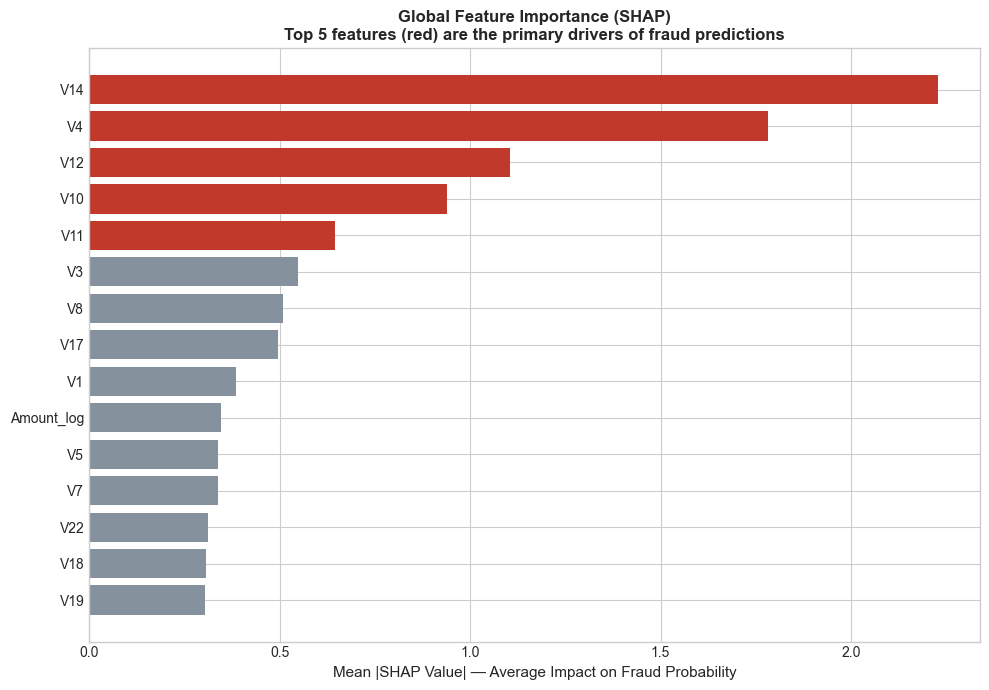

In [4]:
# --- Global Bar Plot: Mean |SHAP| per feature ---
mean_abs_shap = pd.Series(
    np.abs(sv).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(mean_abs_shap.index[:15][::-1],
               mean_abs_shap.values[:15][::-1],
               color=['#c0392b' if i < 5 else '#85929e'
                      for i in range(14, -1, -1)])
ax.set_xlabel('Mean |SHAP Value| — Average Impact on Fraud Probability', fontsize=11)
ax.set_title('Global Feature Importance (SHAP)\n'
             'Top 5 features (red) are the primary drivers of fraud predictions',
             fontweight='bold')
plt.tight_layout()
plt.show()

## 3. SHAP Beeswarm Plot — Feature Impact Direction

The beeswarm plot extends global importance by showing **both the magnitude and direction** of each feature's impact:
- Each dot is one transaction
- **Red dots:** high feature value; **Blue dots:** low feature value
- **X-position:** SHAP value — right means the feature increased fraud probability for that transaction; left means it decreased it

This is the key plot for a fraud analyst asking: *"What does a high V14 value mean for fraud risk?"

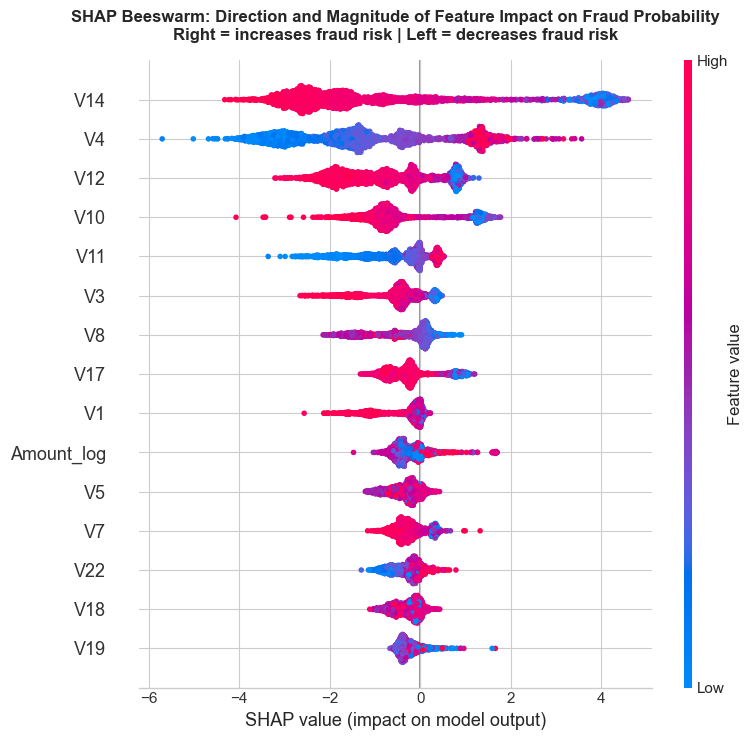

In [5]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv, X_sample,
    feature_names=FEATURE_COLS,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm: Direction and Magnitude of Feature Impact on Fraud Probability\n'
          'Right = increases fraud risk | Left = decreases fraud risk',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 4. Individual Transaction Explanations

This is the **most operationally valuable explainability output** — it tells a fraud analyst exactly why a specific transaction was flagged or approved.

### 4a. A Flagged Fraud Case

The waterfall plot shows how each feature pushes the prediction from the base rate (average fraud probability across all transactions) to the final score. Red bars increase fraud probability; blue bars decrease it.

In [6]:
# Find a true positive: fraud case where model gives high fraud probability
proba_sample = model.predict_proba(X_sample)[:, 1]
fraud_mask   = y_sample.values == 1

# Highest-confidence fraud prediction
fraud_scores  = proba_sample[fraud_mask]
fraud_indices = np.where(fraud_mask)[0]
top_fraud_idx = fraud_indices[np.argmax(fraud_scores)]

print(f'Transaction index : {top_fraud_idx}')
print(f'Fraud probability : {proba_sample[top_fraud_idx]:.4f}')
print(f'Actual label      : {"FRAUD" if y_sample.iloc[top_fraud_idx]==1 else "LEGIT"}')

Transaction index : 426
Fraud probability : 1.0000
Actual label      : FRAUD


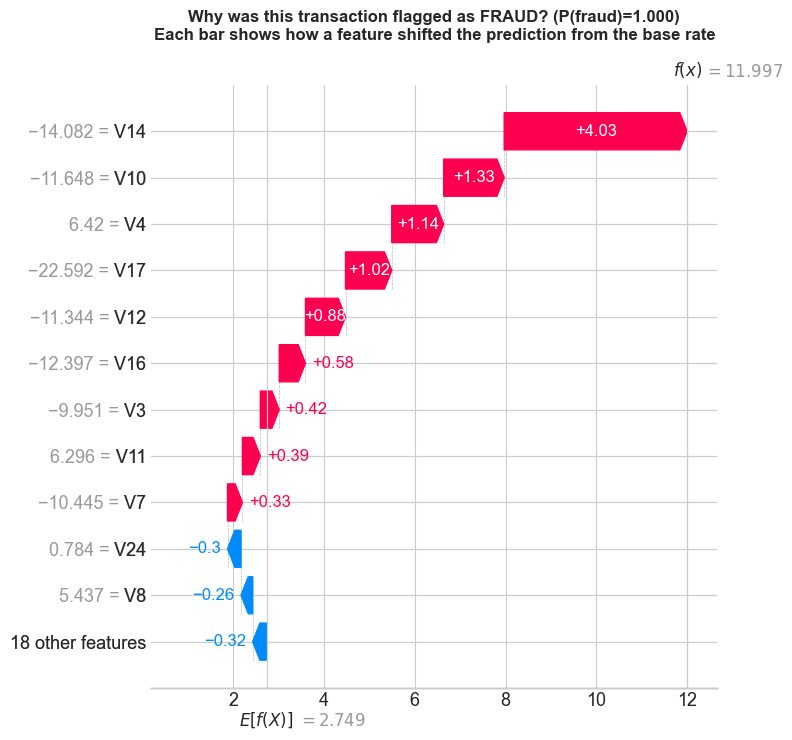

In [7]:
# Waterfall plot for this transaction
shap_exp = shap.Explanation(
    values       = sv[top_fraud_idx],
    base_values  = explainer.expected_value if not isinstance(explainer.expected_value, list)
                   else explainer.expected_value[1],
    data         = X_sample.iloc[top_fraud_idx].values,
    feature_names= FEATURE_COLS
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title(f'Why was this transaction flagged as FRAUD? (P(fraud)={proba_sample[top_fraud_idx]:.3f})\n'
          'Each bar shows how a feature shifted the prediction from the base rate',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 4b. A False Positive — Blocked Legitimate Customer

Understanding why the model incorrectly blocks a legitimate customer is critical for:
- **Customer service:** Explaining the block in a customer-facing message
- **Model improvement:** Identifying systematic errors to address in next model iteration
- **False positive reduction:** Finding features that are misleading the model

In [8]:
# Find a false positive: legitimate transaction flagged as fraud.
# Use the frozen threshold selected on validation data in notebook 02.
legit_mask   = y_sample.values == 0
fp_mask      = legit_mask & (proba_sample >= threshold)
fp_indices   = np.where(fp_mask)[0]

if len(fp_indices) > 0:
    # Highest-confidence false positive (worst case: legitimate tx model is most sure is fraud)
    fp_idx = fp_indices[np.argmax(proba_sample[fp_indices])]

    print(f'Transaction index : {fp_idx}')
    print(f'Fraud probability : {proba_sample[fp_idx]:.4f}')
    print(f'Actual label      : LEGITIMATE (False Positive - customer wrongly flagged)')

    shap_exp_fp = shap.Explanation(
        values       = sv[fp_idx],
        base_values  = explainer.expected_value if not isinstance(explainer.expected_value, list)
                       else explainer.expected_value[1],
        data         = X_sample.iloc[fp_idx].values,
        feature_names= FEATURE_COLS
    )

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp_fp, max_display=12, show=False)
    plt.title(f'Why was this LEGITIMATE transaction flagged? (P(fraud)={proba_sample[fp_idx]:.3f})\n'
              'Understanding false positives is critical for reducing customer friction',
              fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
else:
    print('No false positives in sample at the frozen validation threshold.')


No false positives in sample at the frozen validation threshold.


## 5. SHAP Dependence Plots — Feature Interaction Analysis

Dependence plots reveal the **relationship between a feature's value and its impact on fraud probability**, and can surface interaction effects (e.g., V14's impact on fraud risk changes depending on V12).

This is valuable for fraud strategy teams who want to write rule-based fallback logic informed by the model's learned patterns.

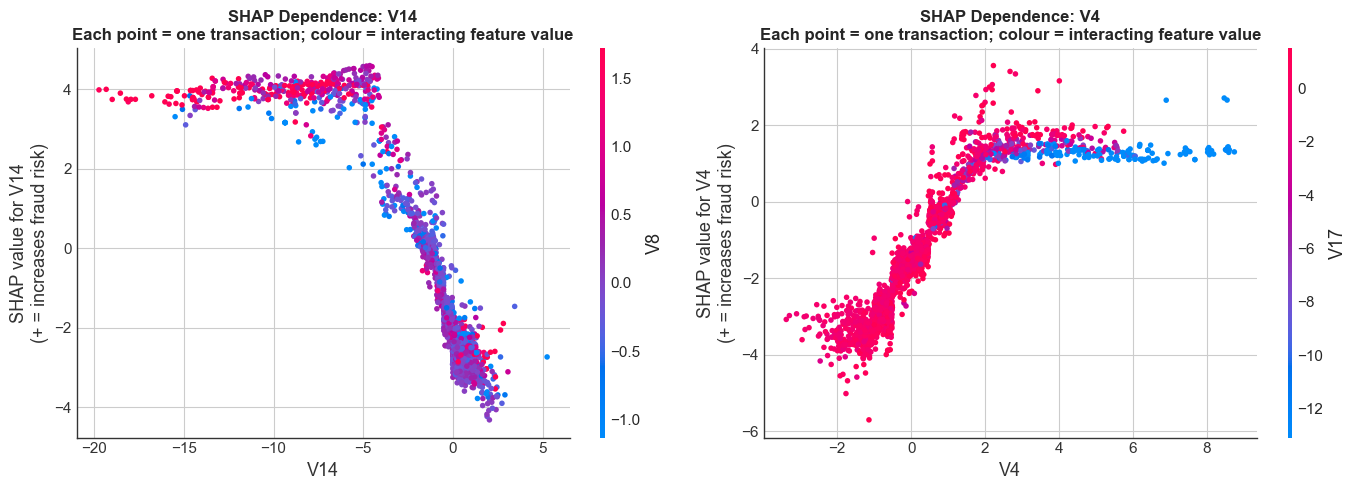

In [9]:
top_2_features = mean_abs_shap.head(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, top_2_features):
    feat_idx = FEATURE_COLS.index(feat)
    shap.dependence_plot(
        feat,
        sv,
        X_sample,
        ax=ax,
        show=False
    )
    ax.set_title(f'SHAP Dependence: {feat}\n'
                 'Each point = one transaction; colour = interacting feature value',
                 fontweight='bold')
    ax.set_ylabel(f'SHAP value for {feat}\n(+ = increases fraud risk)')

plt.tight_layout()
plt.show()

## 6. Fraud vs Legitimate SHAP Value Distributions

Comparing SHAP value distributions between classes shows how the model *separates* fraud from legitimate transactions using each feature — a diagnostic view useful for model validation.

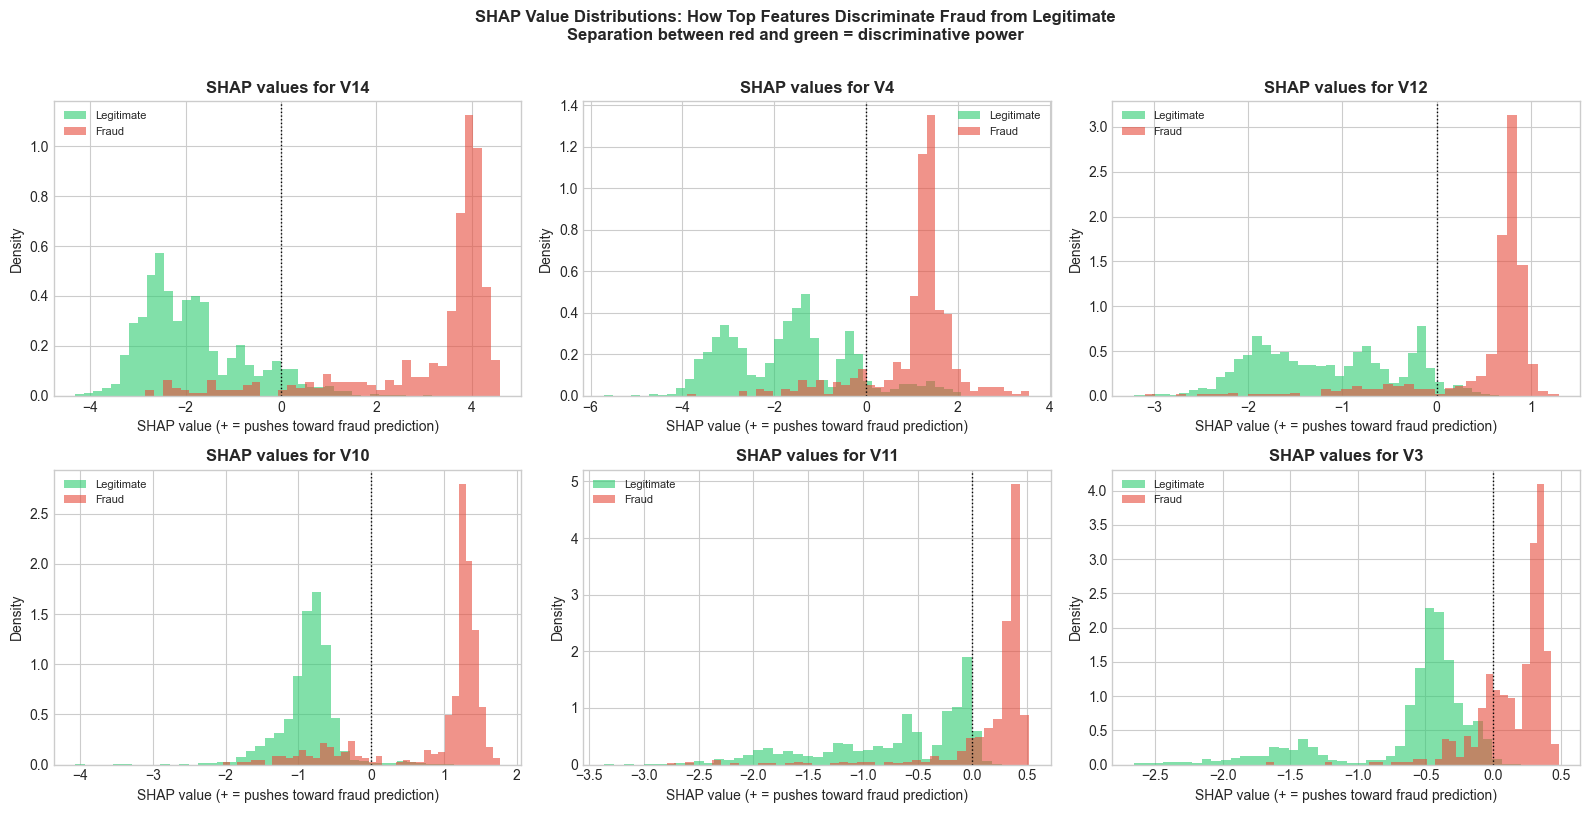

In [10]:
top_features = mean_abs_shap.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    feat_idx   = FEATURE_COLS.index(feat)
    shap_fraud = sv[y_sample.values == 1, feat_idx]
    shap_legit = sv[y_sample.values == 0, feat_idx]

    ax.hist(shap_legit, bins=40, alpha=0.6, color=LEGIT_COLOR,
            density=True, label='Legitimate')
    ax.hist(shap_fraud, bins=40, alpha=0.6, color=FRAUD_COLOR,
            density=True, label='Fraud')
    ax.axvline(0, color='black', linewidth=1, linestyle=':')
    ax.set_title(f'SHAP values for {feat}', fontweight='bold')
    ax.set_xlabel('SHAP value (+ = pushes toward fraud prediction)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('SHAP Value Distributions: How Top Features Discriminate Fraud from Legitimate\n'
             'Separation between red and green = discriminative power',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Model Explanation Summaries

Because `V1`-`V28` are anonymized PCA components, this notebook does not invent business labels for them. The helper below reports the strongest positive and negative SHAP contributors using the real feature names available in the dataset.


In [11]:
def generate_explanation_summary(shap_row: np.ndarray, feature_names: list,
                                 fraud_prob: float, threshold: float,
                                 actual_label: int, top_n: int = 3) -> dict:
    """Summarize a model decision using the actual anonymized feature names."""
    decision = 'FLAG' if fraud_prob >= threshold else 'APPROVE'
    outcome = (
        'true_positive' if decision == 'FLAG' and actual_label == 1 else
        'false_positive' if decision == 'FLAG' and actual_label == 0 else
        'false_negative' if decision == 'APPROVE' and actual_label == 1 else
        'true_negative'
    )

    shap_series = pd.Series(shap_row, index=feature_names)
    top_risk = shap_series[shap_series > 0].sort_values(ascending=False).head(top_n)
    top_mitigants = shap_series[shap_series < 0].sort_values().head(top_n)

    return {
        'decision': decision,
        'actual_label': 'FRAUD' if actual_label == 1 else 'LEGITIMATE',
        'outcome': outcome,
        'fraud_score': round(float(fraud_prob), 4),
        'top_positive_shap_features': top_risk.index.tolist(),
        'top_negative_shap_features': top_mitigants.index.tolist()
    }

# Demo: summarize one high-confidence fraud and, if present, one false positive.
examples = [('True Positive (Fraud flagged)', top_fraud_idx)]
if len(fp_indices) > 0:
    examples.append(('False Positive (Legitimate flagged)', fp_idx))
else:
    tn_candidates = np.where((y_sample.values == 0) & (proba_sample < threshold))[0]
    if len(tn_candidates) > 0:
        tn_idx = tn_candidates[np.argmin(proba_sample[tn_candidates])]
        examples.append(('True Negative (Legitimate approved)', tn_idx))

print('=== Sample Model Explanation Summaries ===\n')
for label, idx in examples:
    summary = generate_explanation_summary(
        sv[idx], FEATURE_COLS,
        proba_sample[idx], threshold,
        int(y_sample.iloc[idx])
    )
    print(f'--- {label} ---')
    for k, v in summary.items():
        print(f'  {k:<28}: {v}')
    print()


=== Sample Model Explanation Summaries ===

--- True Positive (Fraud flagged) ---
  decision                    : FLAG
  actual_label                : FRAUD
  outcome                     : true_positive
  fraud_score                 : 1.0
  top_positive_shap_features  : ['V14', 'V10', 'V4']
  top_negative_shap_features  : ['V24', 'V8', 'V15']

--- True Negative (Legitimate approved) ---
  decision                    : APPROVE
  actual_label                : LEGITIMATE
  outcome                     : true_negative
  fraud_score                 : 0.0
  top_positive_shap_features  : []
  top_negative_shap_features  : ['V14', 'V12', 'V4']



## 8. Explainability Summary

| Explainability Output | Use Case |
|---|---|
| **Global feature importance (SHAP)** | Identify which anonymized features most influence the model |
| **Beeswarm plot** | Inspect direction and spread of feature effects |
| **Individual waterfall plots** | Debug why a specific transaction was flagged or approved |
| **Dependence plots** | Explore feature interactions and non-linear behavior |
| **Explanation summaries** | Compact analyst-facing summaries using actual dataset feature names |

### Honest Interpretation Checklist
- SHAP values are computed for model interpretation and debugging.
- `V1`-`V28` are anonymized PCA components and are not mapped to invented business labels.
- The selected decision threshold comes from the validation workflow in `02_modeling.ipynb`.
- Individual explanations are useful for debugging and analyst review; customer-facing decline explanations would require original business features.
- Monitoring SHAP distributions over time could help detect drift in a fuller production system.


In [12]:
conn.close()
print('Notebook complete.')

Notebook complete.
